# Análise de Correlação entre Idade e Frequência Cardíaca Máxima em Dados de Doença Cardíaca

Este notebook realiza uma análise exploratória e de correlação entre as variáveis 'Idade' e 'Frequência Cardíaca Máxima Alcançada' utilizando um dataset de doença cardíaca. O objetivo é verificar se existe uma correlação linear significativa entre essas duas variáveis.

**Conteúdo:**
- Carregamento e Limpeza dos Dados
- Análise Descritiva das Variáveis Idade e Frequência Cardíaca Máxima
- Visualização da Distribuição das Variáveis
- Visualização da Relação entre Idade e Frequência Cardíaca Máxima
- Análise da Correlação de Pearson entre Idade e Frequência Cardíaca Máxima



### Importando as bibliotecas

In [23]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

### Leitura dos dados

In [24]:
# A URL para o dataset fornecida pelo usuário.
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

# As colunas do dataset não têm cabeçalho. Vamos defini-las.
# Fonte: https://archive.ics.uci.uci.edu/ml/datasets/Heart+Disease
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

### Cria o dataframe

In [25]:
# Carrega o dataset usando pandas.
df = pd.read_csv(url, header=None, names=column_names, na_values='?')

### Análise Exploratória dos Dados (Boas Práticas)

In [26]:
print(df.shape)
df.head(3)

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [28]:
# O teste de Pearson e a visualização não funcionam com valores ausentes.
# Vamos remover as linhas que contêm 'NaN' (Not a Number)
# criados a partir dos '?' originais.
df_clean = df.dropna().copy()

In [29]:
df_clean.shape

(297, 14)

####
--- VISUALIZAÇÃO DA DISTRIBUIÇÃO DE IDADE E FREQUÊNCIA CARDÍACA MÁXIMA ---

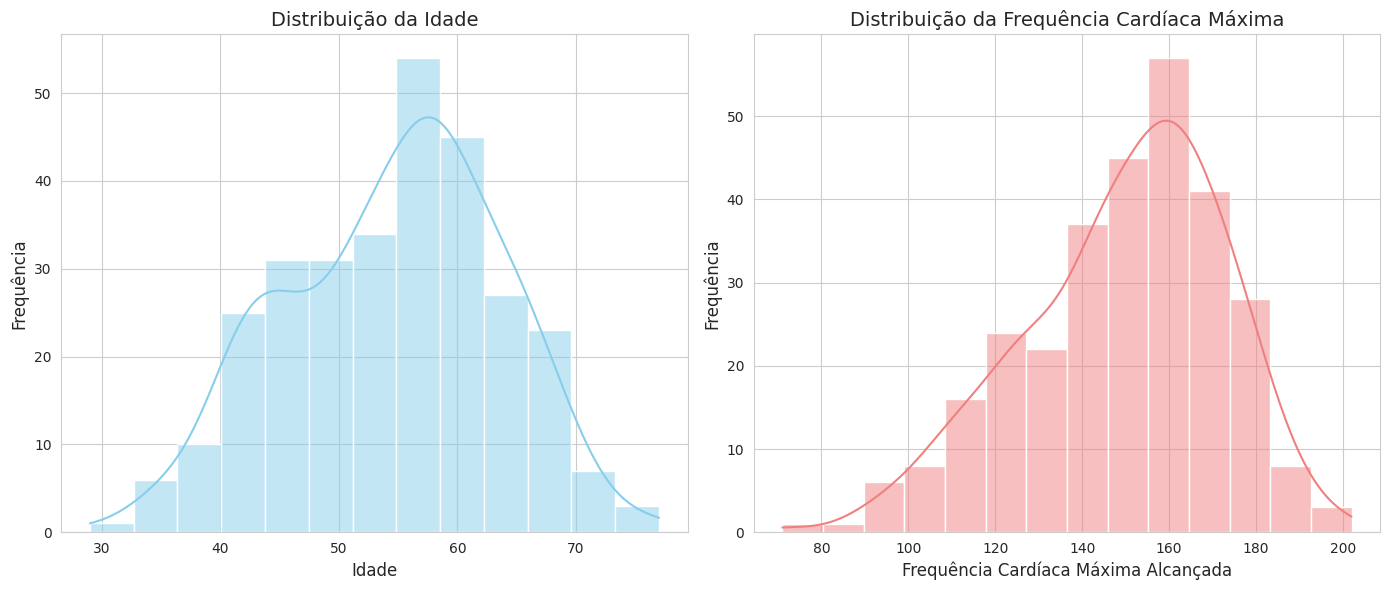

In [30]:
# Configura a figura e os eixos para os dois gráficos lado a lado.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de distribuição para a Idade
sns.histplot(df_clean['age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição da Idade', fontsize=14)
axes[0].set_xlabel('Idade', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)

# Gráfico de distribuição para a Frequência Cardíaca Máxima
sns.histplot(df_clean['thalach'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribuição da Frequência Cardíaca Máxima', fontsize=14)
axes[1].set_xlabel('Frequência Cardíaca Máxima Alcançada', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)

# Ajusta o layout para evitar sobreposição.
plt.tight_layout()

# Exibe os gráficos.
plt.show()

###   --- VISUALIZAÇÃO DA RELAÇÃO ENTRE IDADE E FREQUÊNCIA CARDÍACA MÁXIMA ---

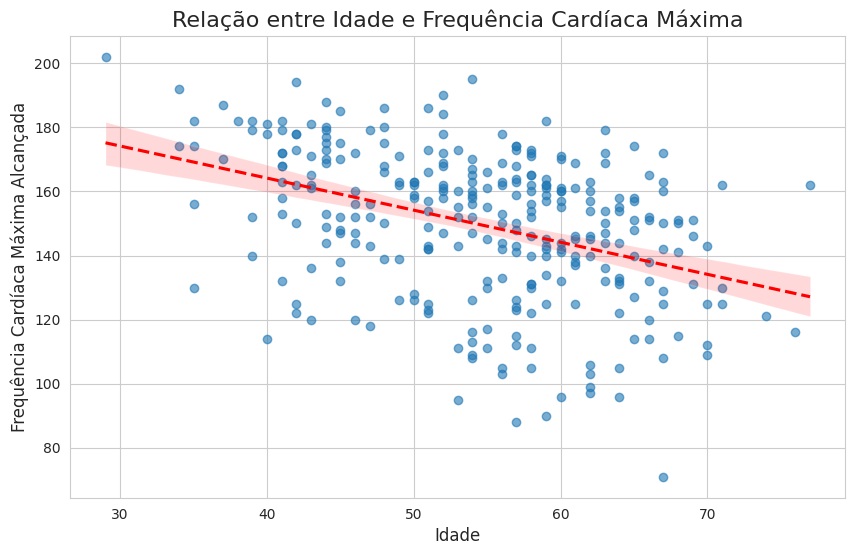

In [31]:
# Define o estilo do gráfico para uma visualização mais agradável.
sns.set_style("whitegrid")

# Cria um gráfico de dispersão (scatter plot) usando a biblioteca seaborn.
# 'regplot' plota os pontos e a linha de regressão linear.
plt.figure(figsize=(10, 6))
sns.regplot(x='age', y='thalach', data=df_clean, ci=95,
            line_kws={'color': 'red', 'linestyle': '--'},
            scatter_kws={'alpha': 0.6})

# Adiciona título e rótulos aos eixos para clareza.
plt.title('Relação entre Idade e Frequência Cardíaca Máxima', fontsize=16)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Frequência Cardíaca Máxima Alcançada', fontsize=12)

# Exibe o gráfico.
plt.show()

### ---  (HEATMAP DE DENSIDADE) PARA IDADE E FREQUÊNCIA CARDÍACA MÁXIMA ---

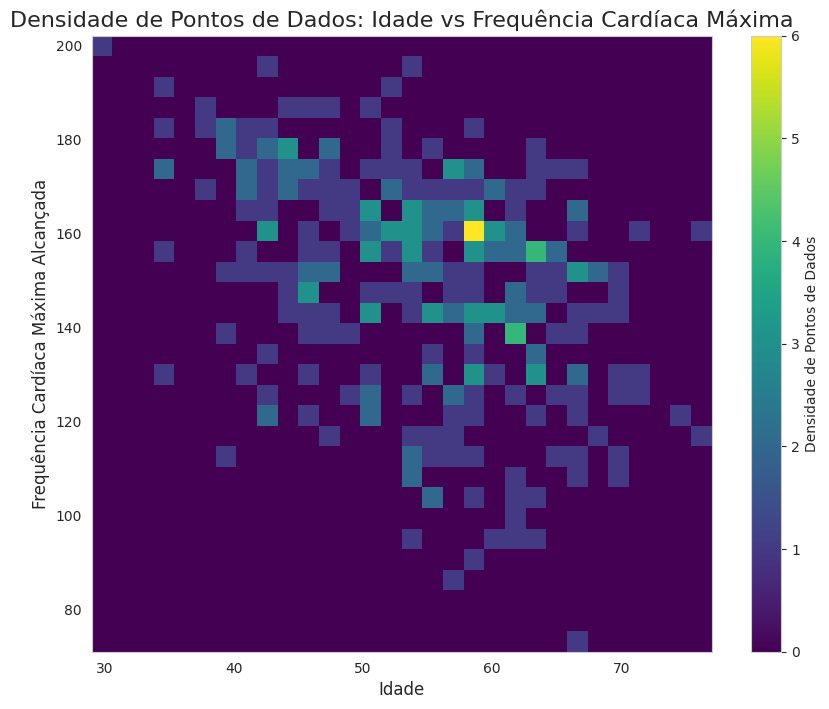

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns # Import seaborn for better aesthetics

# Seleciona as variáveis 'age' e 'thalach' do DataFrame limpo
age_data = df_clean['age']
thalach_data = df_clean['thalach']

# Define o estilo do gráfico para melhor visualização
sns.set_style("whitegrid")

# Cria o histograma 2D (mapa de calor de densidade)
plt.figure(figsize=(10, 8))
plt.hist2d(age_data, thalach_data, bins=30, cmap='viridis') # 'bins' define a granularidade
plt.colorbar(label='Densidade de Pontos de Dados') # Rótulo mais descritivo
plt.xlabel('Idade', fontsize=12) # Rótulo do eixo X
plt.ylabel('Frequência Cardíaca Máxima Alcançada', fontsize=12) # Rótulo do eixo Y
plt.title('Densidade de Pontos de Dados: Idade vs Frequência Cardíaca Máxima', fontsize=16) # Título descritivo

# Exibe o gráfico
plt.show()

### Calcula o coeficiente de correlação de Pearson e o p-valor.

In [33]:
# Converte as colunas 'age' e 'thalach' para tipo numérico.
df_clean['age'] = pd.to_numeric(df_clean['age'])
df_clean['thalach'] = pd.to_numeric(df_clean['thalach'])

# Seleciona as duas variáveis para o teste de correlação.
age = df_clean['age']
thalach = df_clean['thalach']

# Calcula o coeficiente de correlação de Pearson e o p-valor.
correlation_age_thalach, p_value_age_thalach = pearsonr(age, thalach)

# Imprime os resultados para a correlação de Idade vs Frequência Cardíaca Máxima.
print("--- Correlação entre Idade e Frequência Cardíaca Máxima ---")
print(f"Coeficiente de Correlação de Pearson (r): {correlation_age_thalach:.4f}")
print(f"p-valor: {p_value_age_thalach:.4f}")
if p_value_age_thalach < 0.05:
    print("A correlação é estatisticamente significativa.")
else:
    print("A correlação não é estatisticamente significativa.")
print("-" * 50)

--- Correlação entre Idade e Frequência Cardíaca Máxima ---
Coeficiente de Correlação de Pearson (r): -0.3946
p-valor: 0.0000
A correlação é estatisticamente significativa.
--------------------------------------------------


Conclusão:

  Neste caso, **r = -0.3946** sugere uma **correlação linear negativa moderada** entre idade e frequência cardíaca máxima. Isso significa que, à medida que a idade aumenta, a frequência cardíaca máxima tende a diminuir. A linha de regressão no gráfico de dispersão que geramos anteriormente ilustra essa tendência decrescente.

*   **O que significa o p-valor:** O p-valor associado ao teste de correlação nos ajuda a determinar se a correlação observada é estatisticamente significativa, ou seja, se é provável que não seja apenas resultado do acaso. Obtivemos um **p-valor de 0.0000**.

Em resumo, a análise de correlação indica que pessoas mais velhas neste dataset tendem a ter uma frequência cardíaca máxima mais baixa, e essa relação é estatisticamente significativa.

### Fim da Análise